# Global Thresholding

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

[ WARN:0@2121.895] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34016 (0x84e0) encountered
[ WARN:0@2121.895] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34017 (0x84e1) encountered
[ WARN:0@2121.895] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34018 (0x84e2) encountered
[ WARN:0@2121.895] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34019 (0x84e3) encountered
[ WARN:0@2121.895] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34020 (0x84e4) encountered
[ WARN:0@2121.895] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34021 (0x84e5) encountered
[ WARN:0@2121.895] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34022 (0x84e6) encountered
[ WARN:0@2121.895] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34023 (0x84

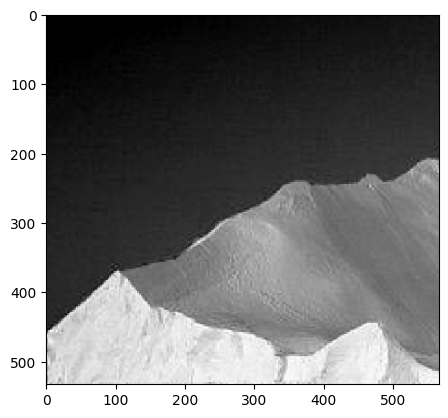

In [9]:
# Read the image
img = cv2.imread('Gonzalez_images/iceberg.tif', 0)
# Display the iamge
plt.imshow(img, cmap='gray')

In [10]:
T = 125 # Initial estimate
threshold_diff = 0.1

In [11]:
while True:
    less_pix = list()
    more_pix = list()

    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            if img[i][j] < T:
                less_pix.append(img[i][j])
            else:
                more_pix.append(img[i][j])

    m1 = sum(less_pix)/len(less_pix)
    m2 = sum(more_pix)/len(more_pix)

    T_new = (m1+m2)/2

    diff = abs(T_new - T)

    if diff<threshold_diff:
        break

    T = T_new

/tmp/ipykernel_23361/2922966839.py:12: RuntimeWarning: overflow encountered in scalar add
  m1 = sum(less_pix)/len(less_pix)
/tmp/ipykernel_23361/2922966839.py:13: RuntimeWarning: overflow encountered in scalar add
  m2 = sum(more_pix)/len(more_pix)


In [12]:
new_img = np.zeros(img.shape)

In [13]:
for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            if img[i][j] > T:
                new_img[i][j] = 255

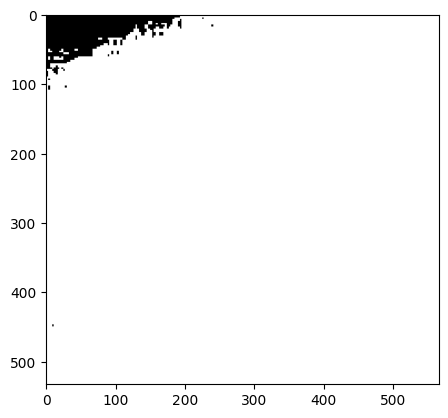

In [14]:
plt.imshow(new_img, cmap='gray')